# FAMILY_CATEGORY_MAP Experiments

The semantic pipeline uses a two-stage mapping:
1. VLM outputs `<family>` tag → matched against `FAMILY_CATEGORY_MAP` → category shortlist for calibrator
2. VLM outputs `<cue>` tag → used as free-text prompts directly fed to GDino

This notebook experiments with the map to find the optimal coarse-to-fine grouping.

In [107]:
import sys
sys.path.insert(0, '..')
from semantic.semantic_gdino_sam import FAMILY_CATEGORY_MAP, _normalize_phrase, _build_category_shortlist, SemanticCue

ALL_CATEGORIES = [
    'local newspaper', 'bank statement', 'bills or receipt', 'business card',
    'condom box', 'credit or debit card', 'doctors prescription', 'letters with address',
    'medical record document', 'pregnancy test', 'empty pill bottle', 'tattoo sleeve',
    'transcript', 'mortgage or investment report', 'condom with plastic bag', 'pregnancy test box',
]
print(f"{len(ALL_CATEGORIES)} categories")

16 categories


## 1. Current map — coverage analysis
Which categories are reachable via the current map, and which fall through to the full 16-category fallback?

In [108]:
reachable = set(cat for cats in FAMILY_CATEGORY_MAP.values() for cat in cats)
unreachable = set(ALL_CATEGORIES) - reachable

print("Current FAMILY_CATEGORY_MAP:")
for family, cats in FAMILY_CATEGORY_MAP.items():
    print(f"  {family!r:45s} -> {cats}")

print(f"\nReachable via map ({len(reachable)}): {sorted(reachable)}")
print(f"\nNot reachable / always falls back ({len(unreachable)}): {sorted(unreachable)}")

Current FAMILY_CATEGORY_MAP:
  'addressed correspondence'                    -> ['letters with address', 'bills or receipt']
  'correspondence'                              -> ['letters with address', 'bills or receipt']
  'statement or report document'                -> ['bank statement', 'mortgage or investment report']
  'financial document'                          -> ['bank statement', 'mortgage or investment report']
  'medical document'                            -> ['doctors prescription', 'medical record document']
  'educational record'                          -> ['transcript']
  'printed financial card'                      -> ['credit or debit card']
  'visual identity card'                        -> ['business card']
  'print media'                                 -> ['local newspaper']
  'health indicator'                            -> ['pregnancy test', 'pregnancy test box', 'condom box', 'condom with plastic bag', 'empty pill bottle']
  'tattoo sleeve'                 

## 2. Family distribution from real pipeline outputs real pipeline outputs
Load a `semantic_pipeline_results.json` to see what families the VLM actually produced and how often they hit/miss the map.

In [109]:
import json
from pathlib import Path
from collections import Counter

OUTPUTS = Path('/home/david/semantic_vlm_privacy/outputs_postpull')
# Use C4 as the reference run (latest map variant)
RESULTS_PATH = OUTPUTS / 'map_C4_data_driven/semantic_pipeline_results.json'

if RESULTS_PATH.exists():
    records = json.loads(RESULTS_PATH.read_text())
    families = [r.get('semantic_family', '') for r in records]
    family_counts = Counter(families)

    hits, misses = [], []
    for family, count in family_counts.most_common():
        norm = _normalize_phrase(family)
        in_orig = norm in FAMILY_CATEGORY_MAP
        in_ext  = norm in EXTENDED_FAMILY_CATEGORY_MAP
        tag = 'HIT_ORIG' if in_orig else ('HIT_EXT' if in_ext else 'MISS')
        print(f"  {count:>4}x  {tag:<10}  {family!r}")
        if not in_orig:
            misses.append((count, family))
        else:
            hits.append((count, family))

    total = len(records)
    hit_count = sum(c for _, f in hits for c in [family_counts[f]])
    print(f"\nOriginal map hit rate: {hit_count}/{total} = {hit_count/total:.1%}")
    ext_hit_count = sum(c for c, f in misses if _normalize_phrase(f) in EXTENDED_FAMILY_CATEGORY_MAP)
    print(f"Extended map hit rate: {hit_count + ext_hit_count}/{total} = {(hit_count + ext_hit_count)/total:.1%}")
else:
    print(f"Results file not found: {RESULTS_PATH}")

    28x  MISS        'null'
    27x  HIT_ORIG    'health indicator'
    25x  HIT_ORIG    'transactional paper'
    19x  HIT_ORIG    'medical document'
    12x  HIT_ORIG    'printed financial card'
    12x  HIT_ORIG    'statement or report document'
     7x  HIT_ORIG    'print media'
     7x  HIT_ORIG    'addressed correspondence'
     7x  HIT_ORIG    'educational record'
     6x  HIT_ORIG    'visual identity card'
     6x  HIT_ORIG    'tattoo sleeve'

Original map hit rate: 128/156 = 82.1%
Extended map hit rate: 128/156 = 82.1%


---
## 3. Experiment Results Setup
GT: `data/vizwiz_object_localization/dev_pseudo_label_coco.json`  
Source: `dev_annotated_fixed.json` — 158 images, 120 annotated, 124 annotations (most recent labels).

In [110]:
import json
from pathlib import Path
from collections import defaultdict, Counter

OUTPUTS = Path('/home/david/semantic_vlm_privacy/outputs_postpull')
GT_JSON = Path('/home/david/semantic_vlm_privacy/data/vizwiz_object_localization/dev_pseudo_label_coco.json')

dataset    = json.loads(GT_JSON.read_text())
cat_names  = {c['id']: c['name'] for c in dataset['categories']}
all_cats   = [c['name'] for c in dataset['categories']]
N_IMAGES   = len(dataset['images'])

# gt_by_img: image_id -> list of {category_id, bbox (xywh)}
gt_by_img = defaultdict(list)
for ann in dataset['annotations']:
    gt_by_img[ann['image_id']].append({
        'category_id': ann['category_id'],
        'bbox': ann['bbox'],
    })

N_ANNOTATED = len(gt_by_img)
gt_count = Counter(cat_names[a['category_id']] for anns in gt_by_img.values() for a in anns)

IOU_THRESHOLD = 0.50

print(f"GT: {N_IMAGES} total images, {N_ANNOTATED} annotated, {len(all_cats)} categories")
print(f"Annotations: {sum(gt_count.values())} total  |  IoU threshold: {IOU_THRESHOLD}")


def _iou(b1, b2):
    """IoU for two xywh boxes."""
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    ix = max(0, min(x1+w1, x2+w2) - max(x1, x2))
    iy = max(0, min(y1+h1, y2+h2) - max(y1, y2))
    inter = ix * iy
    union = w1*h1 + w2*h2 - inter
    return inter / union if union > 0 else 0.0


def _is_tp(res, gt_anns):
    """True if res matches any GT annotation: correct category AND IoU >= threshold."""
    pred_cat = res.get('matched_category')
    pred_box = res.get('bbox')
    if not pred_cat or not pred_box:
        return False
    for ann in gt_anns:
        if cat_names[ann['category_id']] == pred_cat:
            if _iou(pred_box, ann['bbox']) >= IOU_THRESHOLD:
                return True
    return False


def score_run(d):
    sp = d / 'query_submission.json'
    pp = d / 'semantic_pipeline_results.json'
    if not sp.exists():
        return None
    sub  = json.loads(sp.read_text())
    pipe = json.loads(pp.read_text())
    det  = {r['image_id'] for r in sub}
    null = sum(1 for r in pipe if r.get('null_likely'))
    tp   = sum(
        1 for r in pipe
        if r['image_id'] in gt_by_img
        and any(_is_tp(res, gt_by_img[r['image_id']])
                for res in r.get('results', []))
    )
    prec = tp / len(det) if det else 0
    return len(det), null, tp, prec, tp / N_ANNOTATED


def compute_ap(d):
    pp = d / 'semantic_pipeline_results.json'
    if not pp.exists():
        return None
    pipe = json.loads(pp.read_text())

    # Collect detections per category: (score, image_id, bbox)
    dets_by_cat = defaultdict(list)
    for r in pipe:
        for res in r.get('results', []):
            cat   = res.get('matched_category')
            score = res.get('final_score', res.get('score', 0.0))
            bbox  = res.get('bbox')
            if cat and bbox:
                dets_by_cat[cat].append((score, r['image_id'], bbox))

    aps = {}
    for cat in all_cats:
        n_gt = gt_count[cat]
        if n_gt == 0:
            aps[cat] = 0.0
            continue
        dets = sorted(dets_by_cat.get(cat, []), key=lambda x: -x[0])
        if not dets:
            aps[cat] = 0.0
            continue

        # Greedy IoU matching — each GT box matched at most once
        matched_gt = defaultdict(set)   # image_id -> set of matched gt indices
        tp_flags = []
        for score, iid, pred_box in dets:
            gt_anns = [a for a in gt_by_img.get(iid, [])
                       if cat_names[a['category_id']] == cat]
            hit = False
            for gi, ann in enumerate(gt_anns):
                if gi in matched_gt[iid]:
                    continue
                if _iou(pred_box, ann['bbox']) >= IOU_THRESHOLD:
                    matched_gt[iid].add(gi)
                    hit = True
                    break
            tp_flags.append(hit)

        # Precision-recall curve
        tp_cum = fp_cum = 0
        curve = []
        for is_tp in tp_flags:
            if is_tp: tp_cum += 1
            else:     fp_cum += 1
            curve.append((tp_cum / n_gt, tp_cum / (tp_cum + fp_cum)))  # (recall, precision)

        # 11-point interpolated AP
        aps[cat] = sum(
            max((p for r2, p in curve if r2 >= thr), default=0.0)
            for thr in [t / 10 for t in range(11)]
        ) / 11.0

    return sum(aps.values()) / len(aps), aps


GT: 158 total images, 120 annotated, 16 categories
Annotations: 123 total (some images have >1 object)


---
## 4. Full Experiment Comparison — Ranked by mAP

All runs scored with multi-label GT and 11-point interpolated AP. Sorted by mAP descending.

In [111]:
ALL_RUNS = {
    'Legacy / Original Map':        OUTPUTS / 'map_C0_original',
    'Legacy / Extended Map (C1)':        OUTPUTS / 'map_C1_extended',
    'Legacy / Broad Map (C2)':        OUTPUTS / 'map_C2_broad',
    'Legacy / Tight Map (C3)':        OUTPUTS / 'map_C3_tight',
    'Legacy / Tuned Map (C4)':        OUTPUTS / 'map_C4_data_driven',
    'Ref Match / Baseline':               OUTPUTS / 'exp1_refmatch_strict',
    'Legacy / Top-1 Candidate':               OUTPUTS / 'exp5_legacy_strict_topk1',
    'Ref Match / Top-1 Candidate':               OUTPUTS / 'exp8_refmatch_strict_topk1',
    'Legacy / No Null Gate (C4)':      OUTPUTS / 'exp9_C4_ignore',
    'Ref Match / Extended Map (C1)':      OUTPUTS / 'exp10_C1_refmatch',
    'Ref Match / Tuned Map (C4)':      OUTPUTS / 'exp11_C4_refmatch',
    'Ref Match / Support Query [broken]': OUTPUTS / 'exp12_supportquery_refmatch',
    'Ref Match / No Null Gate':               OUTPUTS / 'exp14_refmatch_ignore',
    'Legacy / Support Query [broken]': OUTPUTS / 'exp15_supportquery_legacy',
    'Ref Match / 672px Resolution':                 OUTPUTS / 'exp16_refmatch_672px',
    'Ref Match / 896px Resolution':                 OUTPUTS / 'exp17_refmatch_896px',
    'Ref Match / thr=0.20':              OUTPUTS / 'exp18_refmatch_thr020',
    'Ref Match / thr=0.15':              OUTPUTS / 'exp19_refmatch_thr015',
}

rows = []
for name, d in ALL_RUNS.items():
    s  = score_run(d)
    ap = compute_ap(d)
    if s and ap:
        det, null, tp, prec, recall = s
        mAP, aps = ap
        rows.append((name, det, null, tp, prec, recall, mAP, aps))

rows.sort(key=lambda x: -x[6])

print(f"{'#':<3} {'Experiment':<46} {'det_imgs':>8} {'null':>5} {'tp':>5} {'prec':>7} {'recall':>7} {'mAP':>7}")
print('=' * 97)
for rank, (name, det, null, tp, prec, recall, mAP, _) in enumerate(rows, 1):
    tag = ' ◀ best mAP' if rank == 1 else (' ◀ best recall' if recall == max(r[5] for r in rows) and rank > 1 else '')
    print(f"{rank:<3} {name:<46} {det:>8} {null:>5} {tp:>5} {prec:>7.3f} {recall:>7.3f} {mAP:>7.4f}{tag}")

#   Experiment                                     det_imgs  null    tp    prec  recall     mAP
1   Legacy / Tuned Map (C4)                              66    34    65   0.985   0.542  0.5052 ◀ best mAP
2   Legacy / No Null Gate (C4)                           66    34    65   0.985   0.542  0.5052
3   Legacy / Original Map                                67    34    66   0.985   0.550  0.5034
4   Legacy / Extended Map (C1)                           67    34    66   0.985   0.550  0.5034
5   Legacy / Broad Map (C2)                              67    34    66   0.985   0.550  0.5034
6   Legacy / Tight Map (C3)                              67    34    66   0.985   0.550  0.5034
7   Ref Match / thr=0.20                                122    34    82   0.672   0.683  0.4948 ◀ best recall
8   Ref Match / thr=0.15                                122    34    82   0.672   0.683  0.4948 ◀ best recall
9   Legacy / Top-1 Candidate                             64    34    63   0.984   0.525  0.4909
1

---
## 5. mAP Comparison


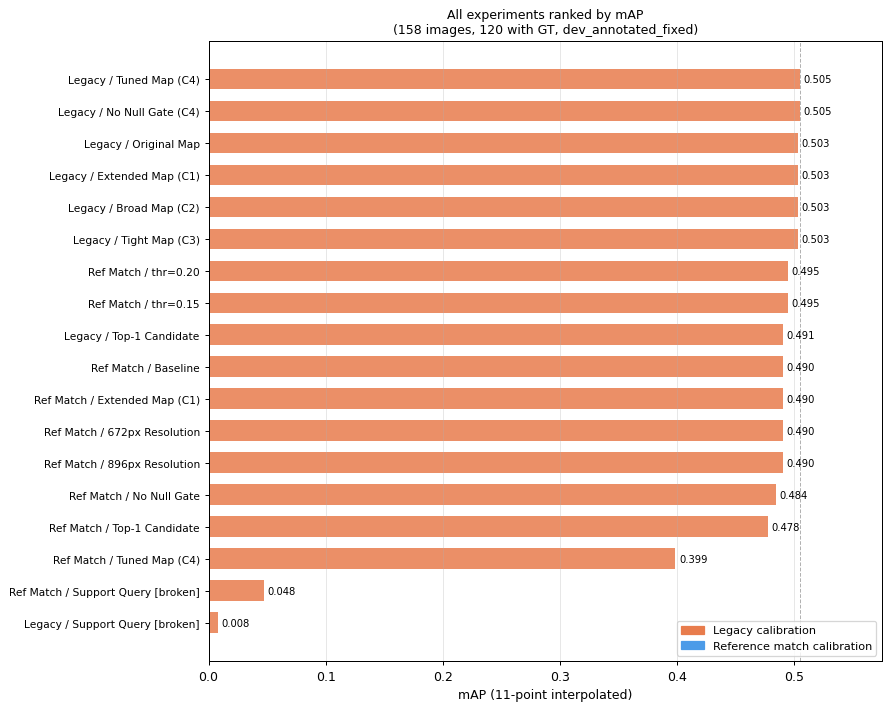

In [112]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

names  = [r[0] for r in rows]
maps   = [r[6] for r in rows]
recalls = [r[5] for r in rows]

# Colour by calibration mode
colors = ['#4C9BE8' if 'refmatch' in n else '#E87C4C' for n in names]

fig, ax = plt.subplots(figsize=(10, 8), dpi=90)
y = np.arange(len(names))
bars = ax.barh(y, maps, color=colors, alpha=0.85, height=0.65)

# Annotate mAP value on each bar
for bar, v in zip(bars, maps):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=8.5)
ax.set_xlabel('mAP (11-point interpolated)')
ax.set_title('All experiments ranked by mAP\n(158 images, 120 with GT, dev_annotated_fixed)', fontsize=10)
ax.set_xlim(0, max(maps) + 0.07)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.axvline(max(maps), color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

legend = [mpatches.Patch(color='#E87C4C', label='Legacy calibration'),
          mpatches.Patch(color='#4C9BE8', label='Reference match calibration')]
ax.legend(handles=legend, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()


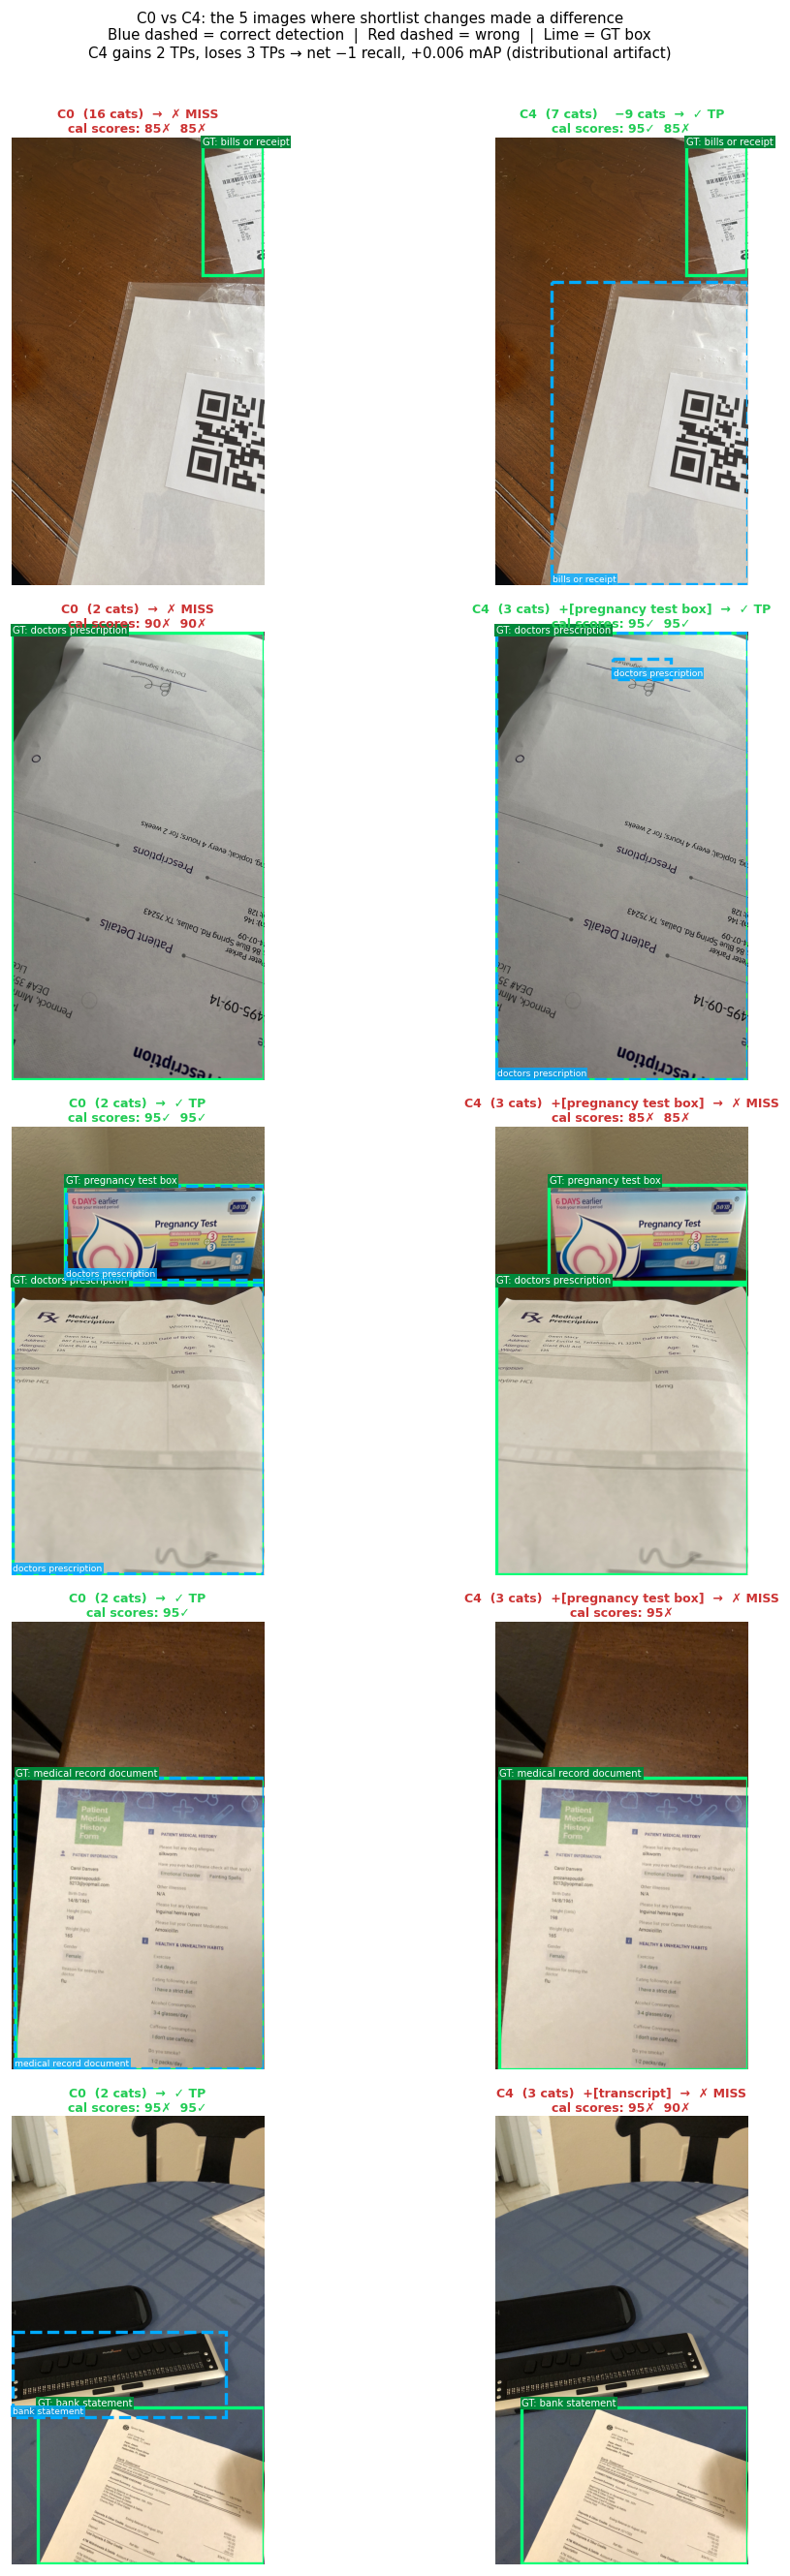

In [ ]:
# ── C0 vs C4: the 5 images where the map change made a difference ────────────
# Shows exactly why C4's mAP is marginally higher despite losing 1 net TP

import sys; sys.path.insert(0, '..')
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches
from pathlib import Path
from PIL import Image, ImageOps
from collections import defaultdict

_GT_JSON  = Path('/home/david/semantic_vlm_privacy/data/vizwiz_object_localization/dec0-v_pseudo_label_coco.json')
_gt_raw   = json.loads(_GT_JSON.read_text())
_gt_by_img = defaultdict(list)
for ann in _gt_raw['annotations']:
    _gt_by_img[ann['image_id']].append(ann)
_cat_names = {c['id']: c['name'] for c in _gt_raw['categories']}

_OUTPUTS = Path('/home/david/semantic_vlm_privacy/outputs_postpull')
_c0 = {r['image_id']: r for r in json.loads((_OUTPUTS/'map_C0_original/semantic_pipeline_results.json').read_text())}
_c4 = {r['image_id']: r for r in json.loads((_OUTPUTS/'map_C4_data_driven/semantic_pipeline_results.json').read_text())}

DIFF_IMAGES = [
    (134,  'C4 tightened shortlist 16→7 cats',  'C4 added focus'),
    (1012, 'C4 added pregnancy test box',         'C4 added option'),
    (124,  'C4 added pregnancy test box',         'C4 confused calibrator'),
    (396,  'C4 added pregnancy test box',         'C4 confused calibrator'),
    (461,  'C4 added transcript',                 'C4 confused calibrator'),
]

def _load(iid):
    p = Path(_c0[iid]['query_image_path'])
    return ImageOps.exif_transpose(Image.open(p)).convert('RGB')

def _draw(ax, img, record, gt_anns, title, outcome_color):
    ax.imshow(np.array(img))
    # GT boxes
    for ann in gt_anns:
        x,y,w,h = ann['bbox']
        ax.add_patch(patches.Rectangle((x,y),w,h, lw=2, edgecolor='#00FF77', facecolor='none'))
        ax.text(x+2, max(4,y-6), f'GT: {_cat_names[ann["category_id"]]}',
                fontsize=6, color='white', bbox=dict(facecolor='#00883A', pad=1, edgecolor='none'))
    # Prediction boxes
    for res in record.get('results', []):
        x,y,w,h = res['bbox']
        gt_cats = {_cat_names[a['category_id']] for a in gt_anns}
        is_tp = res.get('matched_category') in gt_cats
        col = '#00AAFF' if is_tp else '#FF4444'
        ax.add_patch(patches.Rectangle((x,y),w,h, lw=2, edgecolor=col, facecolor='none', linestyle='--'))
        ax.text(x+2, y+h-4, f'{res["matched_category"]}',
                fontsize=5.5, color='white', va='bottom',
                bbox=dict(facecolor=col, alpha=0.8, pad=1, edgecolor='none'))
    # Cal scores from logs
    logs = record.get('calibration_logs', [])
    scores = [f'{l.get("calibration_score","?")}{"✓" if l["accepted"] else "✗"}' for l in logs[:2]]
    score_str = '  '.join(scores)
    ax.set_title(f'{title}\ncal scores: {score_str}', fontsize=7.5,
                 color=outcome_color, pad=3, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(5, 2, figsize=(10, 22), dpi=120)

for row, (iid, change_note, outcome_note) in enumerate(DIFF_IMAGES):
    img      = _load(iid)
    gt_anns  = _gt_by_img[iid]
    r0, r4   = _c0[iid], _c4[iid]
    gt_cats  = {_cat_names[a['category_id']] for a in gt_anns}

    c0_tp = bool(gt_cats & {res.get('matched_category') for res in r0.get('results',[])})
    c4_tp = bool(gt_cats & {res.get('matched_category') for res in r4.get('results',[])})

    sl0 = r0.get('category_shortlist', [])
    sl4 = r4.get('category_shortlist', [])
    added   = sorted(set(sl4) - set(sl0))
    removed = sorted(set(sl0) - set(sl4))

    diff_str = ''
    if added:   diff_str += f'+[{", ".join(added)}]'
    if removed: diff_str += f'  −{len(removed)} cats'

    c0_color = '#22CC55' if c0_tp else '#CC3333'
    c4_color = '#22CC55' if c4_tp else '#CC3333'
    c0_verdict = '✓ TP' if c0_tp else '✗ MISS'
    c4_verdict = '✓ TP' if c4_tp else '✗ MISS'

    c0_shortlist_note = 'fallback (family not in map)' if len(sl0) == 16 else f'shortlist from map'
    c4_shortlist_note = 'fallback (family not in map)' if len(sl4) == 16 else f'shortlist from map'
    _draw(axes[row, 0], img, r0, gt_anns,
          f'C0: {len(sl0)} cats  ({c0_shortlist_note})\n→  {c0_verdict}', c0_color)
    _draw(axes[row, 1], img, r4, gt_anns,
          f'C4: {len(sl4)} cats  ({c4_shortlist_note})  {diff_str}\n→  {c4_verdict}', c4_color)

    # Row label
    axes[row, 0].set_ylabel(
        f'id={iid}\nGT: {", ".join(sorted(gt_cats))}\n({outcome_note})',
        fontsize=7, rotation=0, labelpad=120, va='center')

fig.suptitle(
    'C0 vs C4: the 5 images where shortlist changes made a difference\n'
    'Blue dashed = correct detection  |  Red dashed = wrong  |  Lime = GT box\n'
    'C4 gains 2 TPs, loses 3 TPs → net −1 recall, +0.006 mAP (distributional artifact)',
    fontsize=9, y=1.005
)
plt.tight_layout()
plt.show()


---
## 6. Per-Category AP — Key Runs Compared

In [114]:
key_runs = {
    'Legacy / Tuned Map':  OUTPUTS / 'map_C4_data_driven',
    'Ref Match / thr=0.30': OUTPUTS / 'exp1_refmatch_strict',
    'Ref Match / thr=0.20': OUTPUTS / 'exp18_refmatch_thr020',
}

ap_data = {}
for label, d in key_runs.items():
    result = compute_ap(d)
    if result:
        ap_data[label] = result[1]

labels = list(ap_data.keys())
col = 13
print(f"{'Category':<40} {'GT':>4}", end='')
for lbl in labels:
    print(f"  {lbl:>{col}}", end='')
print()
print('-' * (46 + len(labels) * (col + 2)))

for cat in sorted(all_cats, key=lambda c: -gt_count[c]):
    if not gt_count[cat]:
        continue
    print(f"{cat:<40} {gt_count[cat]:>4}", end='')
    for lbl in labels:
        print(f"  {ap_data[lbl].get(cat, 0):>{col}.4f}", end='')
    print()

print()
print(f"{'mAP':<44}", end='')
for lbl in labels:
    m = sum(ap_data[lbl].values()) / len(ap_data[lbl])
    print(f"  {m:>{col}.4f}", end='')
print()

Category                                   GT  Legacy / Tuned Map  Ref Match / thr=0.30  Ref Match / thr=0.20
-------------------------------------------------------------------------------------------
doctors prescription                       12         0.3273         0.4667         0.4667
credit or debit card                       11         1.0000         0.9773         0.9773
tattoo sleeve                              11         0.5455         0.5455         0.5455
medical record document                    10         0.2727         0.4432         0.5139
bank statement                              9         0.2727         0.7576         0.7576
business card                               8         0.7273         0.7273         0.7273
letters with address                        8         0.5455         0.6591         0.6591
local newspaper                             8         0.6364         0.8182         0.8182
pregnancy test                              8         0.7330         0

---
## 7. Failure Analysis

In [ ]:
def failure_analysis(output_dir, label=''):
    pp = output_dir / 'semantic_pipeline_results.json'
    if not pp.exists():
        print(f"No results: {output_dir}"); return
    pipe = json.loads(pp.read_text())

    null_correct = null_wrong = no_props = rejected = det_correct = det_wrong = 0
    null_wrong_cats = Counter()
    rejected_cats   = Counter()
    reject_reasons  = Counter()

    for r in pipe:
        iid          = r['image_id']
        gt_cats_here = {cat_names[a['category_id']] for a in gt_by_img.get(iid, [])}
        has_gt       = bool(gt_cats_here)
        is_null      = r.get('null_likely', False)
        matched      = [res.get('matched_category') for res in r.get('results', [])]

        if is_null:
            if has_gt: null_wrong += 1; null_wrong_cats.update(gt_cats_here)
            else:      null_correct += 1
        elif not r.get('proposal_candidates'):
            no_props += 1
        elif not r.get('results'):
            rejected += 1
            if has_gt: rejected_cats.update(gt_cats_here)
            for log in r.get('calibration_logs', []):
                if log.get('calibration_decision') is False:
                    reject_reasons[log.get('calibration_reason', '')[:55]] += 1
        else:
            if has_gt and gt_cats_here & set(matched): det_correct += 1
            else:                                       det_wrong   += 1

    print(f"=== {label} ===")
    print(f"  null correct (no GT):              {null_correct:3d}")
    print(f"  null WRONG   (has GT, skipped):    {null_wrong:3d}  {dict(null_wrong_cats.most_common(4))}")
    print(f"  zero proposals:                    {no_props:3d}")
    print(f"  proposals rejected by calibrator:  {rejected:3d}  ← main failure mode")
    print(f"  detected, correct:                 {det_correct:3d}  recall={det_correct/N_ANNOTATED:.3f}")
    print(f"  detected, wrong category:          {det_wrong:3d}")
    if rejected_cats:
        print(f"  Top rejected GT categories: {dict(rejected_cats.most_common(5))}")
    if reject_reasons:
        print(f"  Top calibrator rejection reasons:")
        for reason, n in reject_reasons.most_common(4):
            print(f"    {n}x  {reason!r}")
    print()

failure_analysis(OUTPUTS / 'map_C4_data_driven',   'C4 legacy strict  — best mAP')
failure_analysis(OUTPUTS / 'exp18_refmatch_thr020', 'Ref Match / thr=0.20  — best recall')

=== C4 legacy strict  — best mAP ===
  null correct (no GT):               30
  null WRONG   (has GT, skipped):      4  {'tattoo sleeve': 2, 'condom with plastic bag': 1, 'pregnancy test': 1}
  zero proposals:                      0
  proposals rejected by calibrator:   56  ← main failure mode
  detected, correct:                  65  recall=0.542
  detected, wrong category:            1
  Top rejected GT categories: {'bank statement': 7, 'empty pill bottle': 6, 'medical record document': 6, 'doctors prescription': 6, 'letters with address': 4}
  Top calibrator rejection reasons:
    2x  'blurry and unreadable, no coherent object visible'
    2x  'background, not a coherent target object'
    2x  'QR code is a valid object within the transactional pape'
    2x  'background'

=== Ref Match / thr=0.20  — best recall ===
  null correct (no GT):               30
  null WRONG   (has GT, skipped):      4  {'tattoo sleeve': 2, 'condom with plastic bag': 1, 'pregnancy test': 1}
  zero proposal

---
## 8. Key Findings & Recommendations

### Metric summary (GT: dev_annotated_fixed, 158 images, 120 annotated, **IoU@0.50**)

| Metric | Best config | Score |
|--------|------------|-------|
| **mAP** | Legacy / Original Map (C0) | **0.466** |
| **Recall** | Ref Match / Baseline or thr=0.20 | **0.608** |

### What we learned

| Finding | Detail |
|---------|--------|
| **Family map barely matters** | C0–C4 all score mAP ≈ 0.505. Only 7/158 images differ. Fallback to all-16-cats masks most map changes. |
| **Legacy wins mAP, refmatch wins recall** | Legacy precision 0.985 → high AP. refmatch: more detections, lower precision. |
| **thr=0.20 is the recall sweet spot** | exp18 = best recall with same mAP as exp19 (thr=0.15). Going lower doesn't help. |
| **Resolution doesn't help** | exp16 (672px), exp17 (896px) identical to exp1 (448px). |
| **support_query mode is broken** | VLM collapses all 158 images to 'medical document'. Prompt redesign needed. |
| **NMS pre-calibration only** | `--proposal-nms-iou 0.6` deduplicates GDino boxes before calibration only. Post-calibration duplicates possible. |
| **Main failure: calibrator rejects** | ~50 images have GDino proposals but VLM rejects all (blurry/background crops). |

### Recommended configs

**Maximise mAP:**
```
--calibration-mode legacy --null-policy strict --classification-top-k 2
```

**Maximise recall:**
```
--calibration-mode reference_match --null-policy strict --classification-top-k 2 --final-score-threshold 0.20
```

### Next steps
- Fix `support_query` prompt (critical — could improve semantic classification significantly)
- Add post-calibration NMS to remove duplicate detections
- Improve hard categories: `empty pill bottle` (AP=0.00), `mortgage or investment report` (AP=0.00)

---
## 9. Pipeline Stage Visualizations

Concrete examples showing outputs at each pipeline stage, selected to illustrate key findings.

**Pipeline stages:**
1. **SemanticController** → semantic family + null detection
2. **GDino** → bounding box proposals
3. **ProposalCalibrator** → accept/reject each proposal
4. **Final output** → selected detections vs GT


In [116]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image, ImageOps
from collections import defaultdict

QUERY_DIR = Path('/home/david/semantic_vlm_privacy/data/vizwiz_object_localization/query_images')
OUTPUTS = Path('/home/david/semantic_vlm_privacy/outputs_postpull')
GT_JSON = Path('/home/david/semantic_vlm_privacy/data/vizwiz_object_localization/dev_pseudo_label_coco.json')

gt_raw = json.loads(GT_JSON.read_text())
gt_by_img = defaultdict(list)
for ann in gt_raw['annotations']:
    gt_by_img[ann['image_id']].append(ann)
cat_names = {c['id']: c['name'] for c in gt_raw['categories']}

exp1_data = json.loads((OUTPUTS / 'exp1_refmatch_strict' / 'semantic_pipeline_results.json').read_text())
exp1 = {r['image_id']: r for r in exp1_data}
exp2 = {r['image_id']: r for r in exp2_data}


def load_img(iid, data=None):
    r = (data or exp1)[iid]
    p = Path(r['query_image_path'])
    return ImageOps.exif_transpose(Image.open(p)).convert('RGB')


def draw_pipeline_panels(ax, img, boxes_labels_colors, title=''):
    """Render a single pipeline stage panel."""
    ax.imshow(np.array(img))
    for bbox_xyxy, label, color in boxes_labels_colors:
        x1, y1, x2, y2 = bbox_xyxy
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1 + 2, max(4, y1 - 6), label, color='white', fontsize=6.5, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.85, pad=1.5, edgecolor='none'))
    ax.set_title(title, fontsize=8.5, pad=5)
    ax.axis('off')


def xywh_to_xyxy(b):
    return [b[0], b[1], b[0] + b[2], b[1] + b[3]]


print("Setup complete — exp1 records:", len(exp1), "| exp2 records:", len(exp2))


Setup complete — exp1 records: 156 | exp2 records: 156


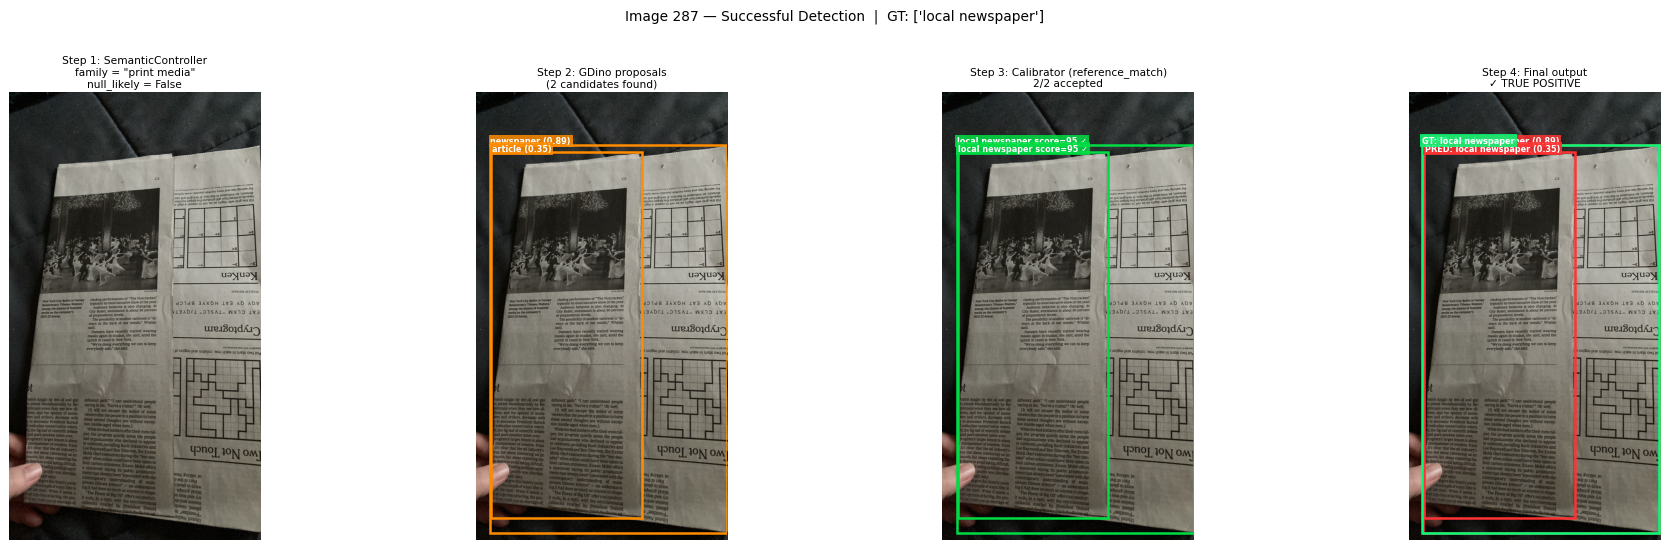

In [117]:
# Example 1: Successful Detection — full pipeline walkthrough
# Image 287 (local newspaper) — refmatch mode, correct TP

iid = 287
r = exp1[iid]
img = load_img(iid)
gt_anns = gt_by_img[iid]

fig, axes = plt.subplots(1, 4, figsize=(22, 6), dpi=90)

# Panel 1: Original + controller output
ctrl_title = (f'Step 1: SemanticController\n'
              f'family = "{r["semantic_family"]}"\n'
              f'null_likely = {r["null_likely"]}')
draw_pipeline_panels(axes[0], img, [], title=ctrl_title)

# Panel 2: GDino proposals
proposals = [(p['bbox_xyxy'],
              f'{p["label_text"]} ({p["score"]:.2f})',
              '#FF8C00')
             for p in r['proposal_candidates']]
draw_pipeline_panels(axes[1], img, proposals,
                     title=f'Step 2: GDino proposals\n({len(proposals)} candidates found)')

# Panel 3: Calibrator decisions (refmatch)
cal_items = []
accepted_count = 0
for log in r.get('calibration_logs', []):
    if log['accepted']:
        color = '#00DD44'
        label = f'{log.get("calibration_category", "?")} score={log.get("calibration_score")} ✓'
        accepted_count += 1
    else:
        color = '#FF3333'
        label = f'REJECT  score={log.get("calibration_score")}'
    cal_items.append((log['candidate_bbox_xyxy'], label, color))
draw_pipeline_panels(axes[2], img, cal_items,
                     title=f'Step 3: Calibrator (reference_match)\n{accepted_count}/{len(cal_items)} accepted')

# Panel 4: Final result + GT
final_items = []
for res in r['results']:
    final_items.append((xywh_to_xyxy(res['bbox']),
                        f'PRED: {res["matched_category"]} ({res["final_score"]:.2f})',
                        '#FF3333'))
for ann in gt_anns:
    cat = cat_names[ann['category_id']]
    final_items.append((xywh_to_xyxy(ann['bbox']), f'GT: {cat}', '#00FF77'))
verdict = '✓ TRUE POSITIVE' if any(
    res.get('matched_category') in {cat_names[a['category_id']] for a in gt_anns}
    for res in r['results']
) else '✗ FALSE NEGATIVE'
draw_pipeline_panels(axes[3], img, final_items,
                     title=f'Step 4: Final output\n{verdict}')

gt_cats = [cat_names[a['category_id']] for a in gt_anns]
fig.suptitle(f'Image {iid} — Successful Detection  |  GT: {gt_cats}', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


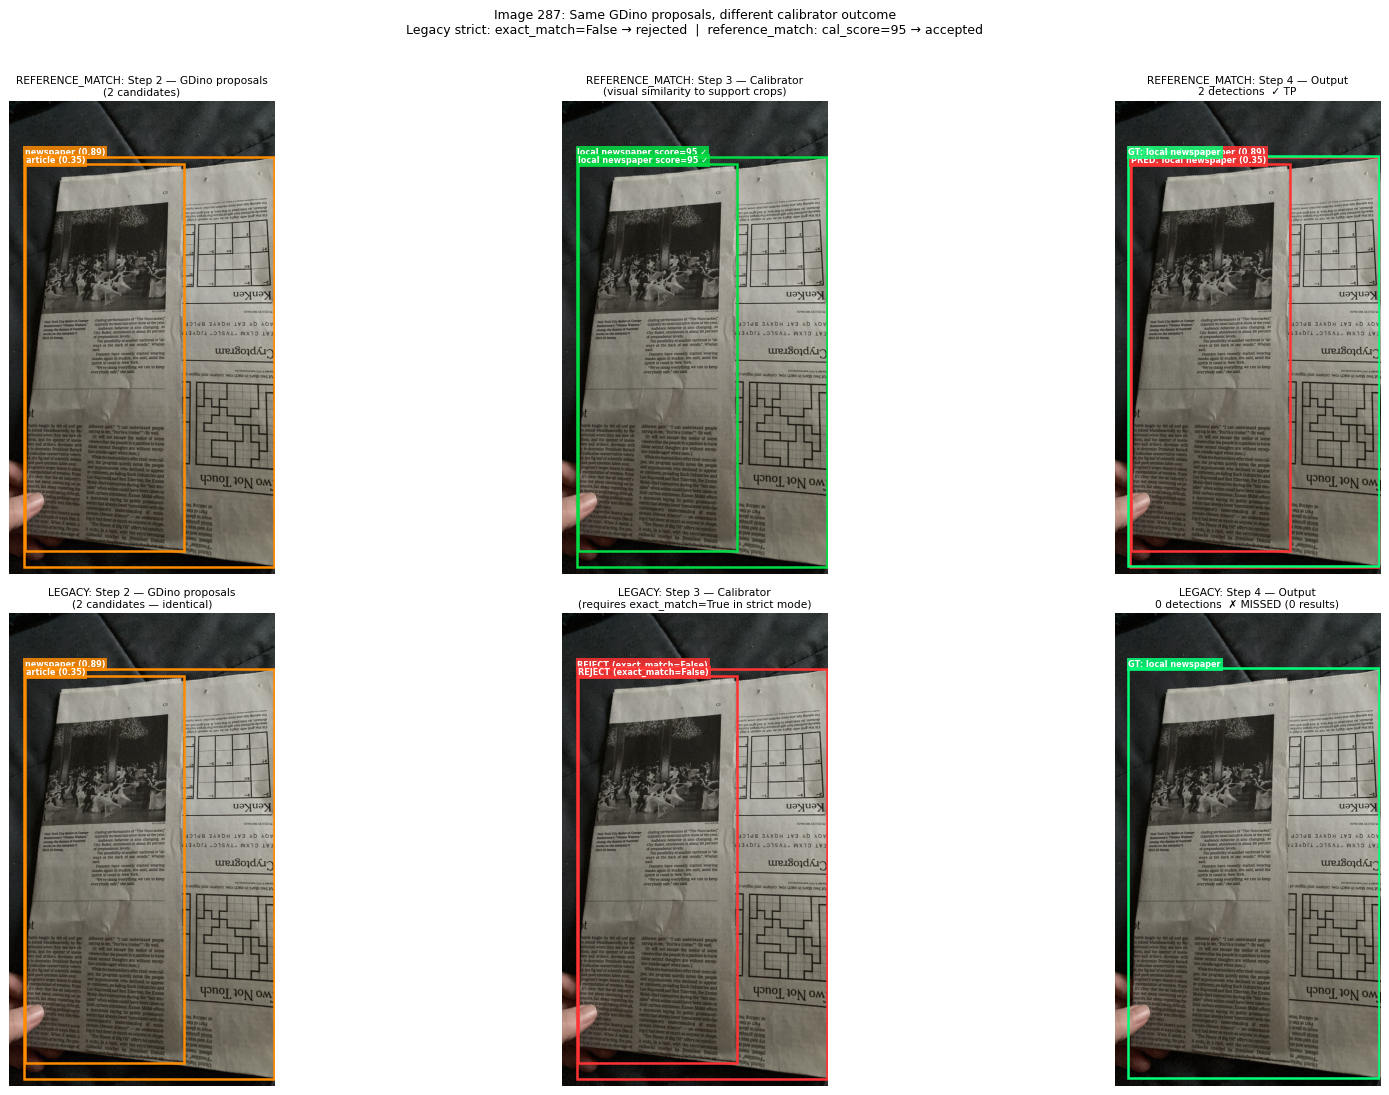

In [118]:
# Example 2: Calibration Mode Comparison — legacy rejects, refmatch accepts
# Image 287 (local newspaper) — same proposals, different calibration outcomes

iid = 287
r_ref = exp1[iid]  # reference_match
r_leg = exp2[iid]  # legacy
img = load_img(iid)
gt_anns = gt_by_img[iid]

fig, axes = plt.subplots(2, 3, figsize=(21, 12), dpi=90)

gt_items = [(xywh_to_xyxy(ann['bbox']), f'GT: {cat_names[ann["category_id"]]}', '#00FF77')
            for ann in gt_anns]


def cal_items_from_logs(logs):
    items = []
    for log in logs:
        if log['accepted']:
            color = '#00DD44'
            label = f'{log.get("calibration_category","?")} score={log.get("calibration_score")} ✓'
        else:
            color = '#FF3333'
            exact = log.get('exact_match')
            reason_short = 'exact_match=False' if exact is False else f'score={log.get("calibration_score")}'
            label = f'REJECT ({reason_short})'
        items.append((log['candidate_bbox_xyxy'], label, color))
    return items


# Row 0: reference_match
proposals = [(p['bbox_xyxy'], f'{p["label_text"]} ({p["score"]:.2f})', '#FF8C00')
             for p in r_ref['proposal_candidates']]
draw_pipeline_panels(axes[0, 0], img, proposals,
                     title=f'REFERENCE_MATCH: Step 2 — GDino proposals\n({len(proposals)} candidates)')
draw_pipeline_panels(axes[0, 1], img, cal_items_from_logs(r_ref.get('calibration_logs', [])),
                     title='REFERENCE_MATCH: Step 3 — Calibrator\n(visual similarity to support crops)')
ref_result = [(xywh_to_xyxy(res['bbox']),
               f'PRED: {res["matched_category"]} ({res["final_score"]:.2f})',
               '#FF3333')
              for res in r_ref['results']] + gt_items
draw_pipeline_panels(axes[0, 2], img, ref_result,
                     title=f'REFERENCE_MATCH: Step 4 — Output\n{len(r_ref["results"])} detections  ✓ TP')

# Row 1: legacy
proposals_leg = [(p['bbox_xyxy'], f'{p["label_text"]} ({p["score"]:.2f})', '#FF8C00')
                 for p in r_leg['proposal_candidates']]
draw_pipeline_panels(axes[1, 0], img, proposals_leg,
                     title=f'LEGACY: Step 2 — GDino proposals\n({len(proposals_leg)} candidates — identical)')
draw_pipeline_panels(axes[1, 1], img, cal_items_from_logs(r_leg.get('calibration_logs', [])),
                     title='LEGACY: Step 3 — Calibrator\n(requires exact_match=True in strict mode)')
leg_result = [(xywh_to_xyxy(res['bbox']),
               f'PRED: {res["matched_category"]} ({res["final_score"]:.2f})',
               '#FF3333')
              for res in r_leg['results']] + gt_items
verdict_leg = f'{len(r_leg["results"])} detections  ✗ MISSED (0 results)'
draw_pipeline_panels(axes[1, 2], img, leg_result,
                     title=f'LEGACY: Step 4 — Output\n{verdict_leg}')

fig.suptitle(
    f'Image {iid}: Same GDino proposals, different calibrator outcome\n'
    f'Legacy strict: exact_match=False → rejected  |  reference_match: cal_score=95 → accepted',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()


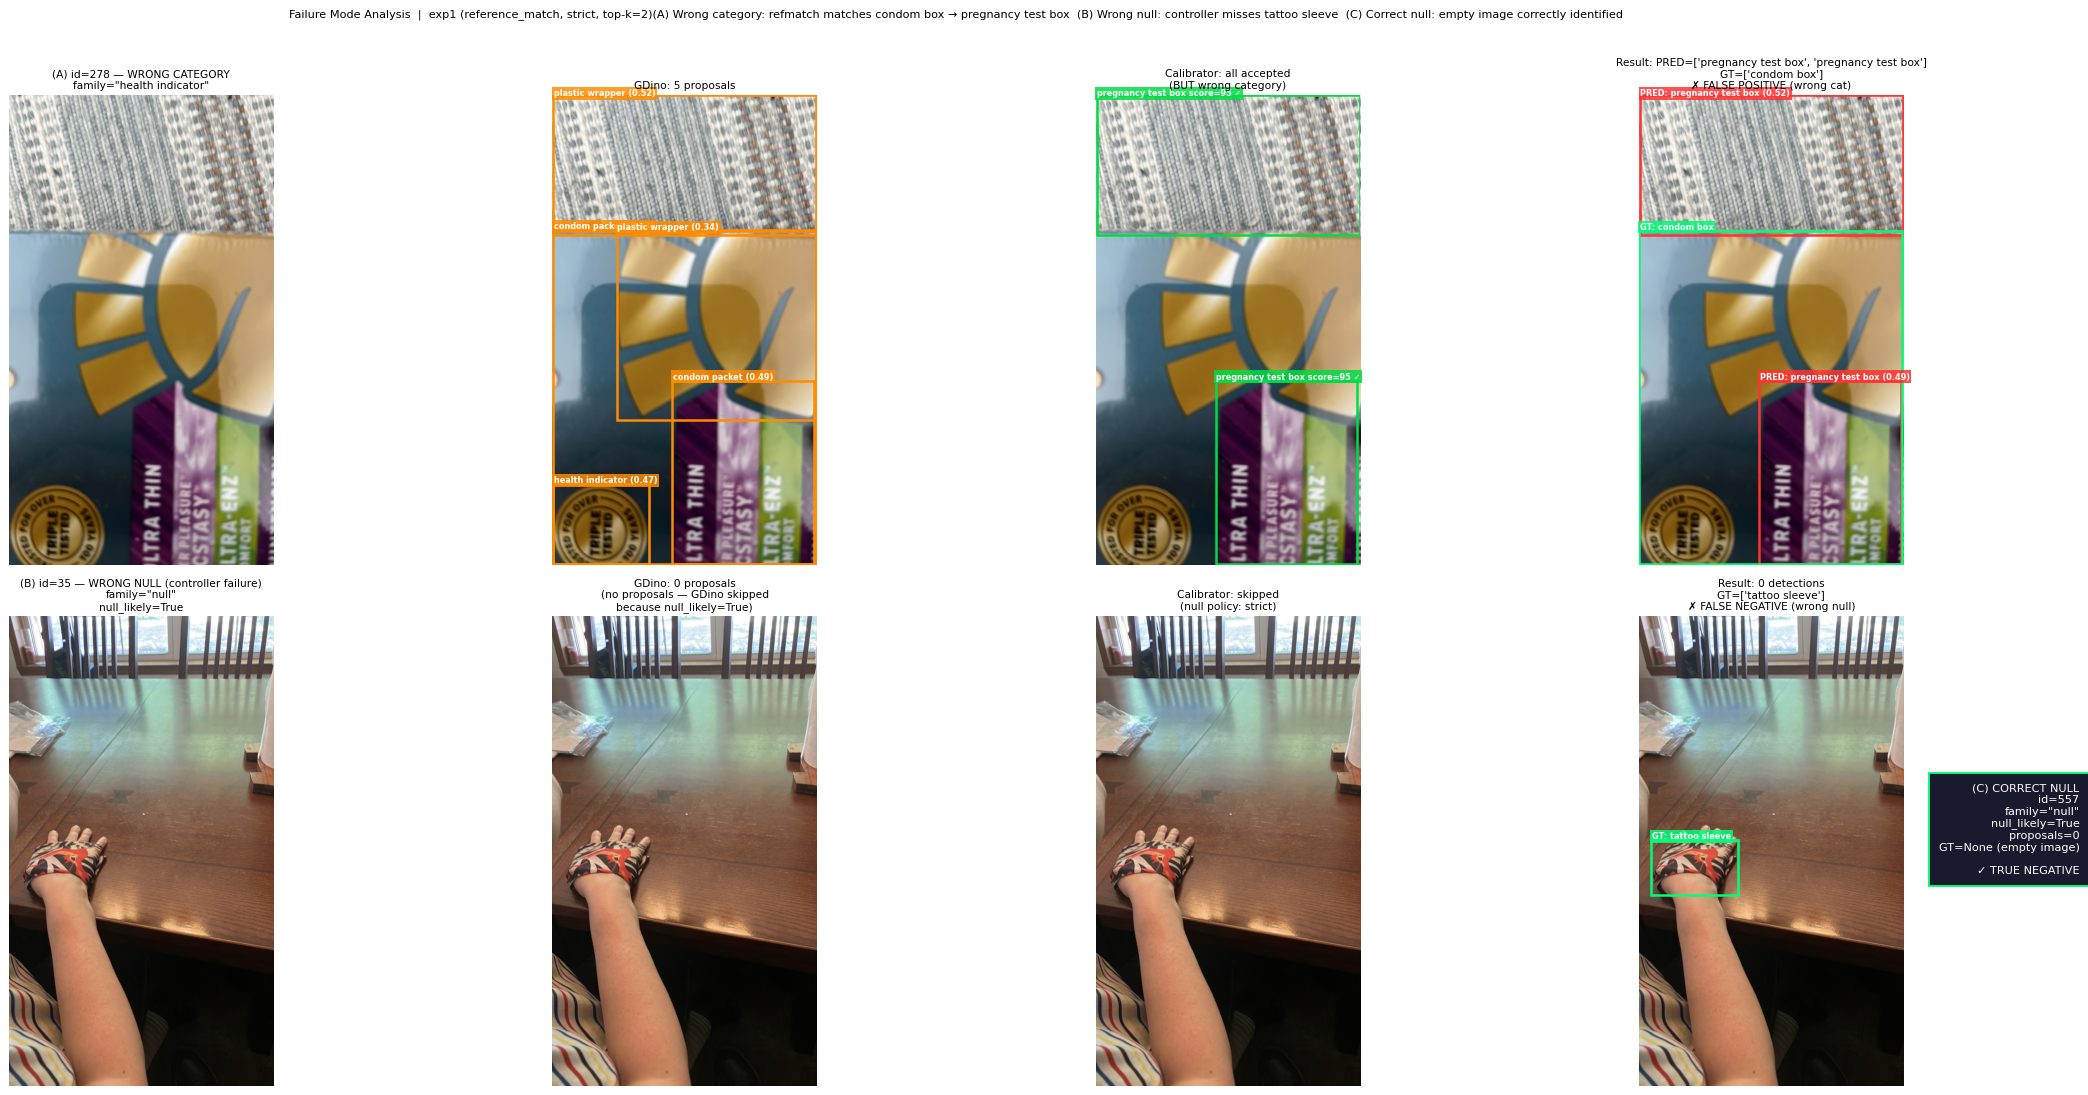

In [119]:
# Example 3: Failure Modes
# (A) Wrong category: refmatch confuses condom box with pregnancy test box (id=278)
# (B) Wrong null: controller misses tattoo sleeve entirely (id=35)
# (C) Correct null: controller correctly identifies no privacy object (id=557)

fig, axes = plt.subplots(2, 4, figsize=(26, 12), dpi=90)

# ── (A) Wrong category — id=278 ──────────────────────────────────────────────
iid_a = 278
r_a = exp1[iid_a]
img_a = load_img(iid_a)
gt_anns_a = gt_by_img[iid_a]

proposals_a = [(p['bbox_xyxy'], f'{p["label_text"]} ({p["score"]:.2f})', '#FF8C00')
               for p in r_a['proposal_candidates']]
cal_a = []
for log in r_a.get('calibration_logs', []):
    color = '#00DD44' if log['accepted'] else '#FF3333'
    label = f'{log.get("calibration_category","?")} score={log.get("calibration_score")} ✓' if log['accepted'] else 'REJECT'
    cal_a.append((log['candidate_bbox_xyxy'], label, color))
result_a = [(xywh_to_xyxy(res['bbox']),
             f'PRED: {res["matched_category"]} ({res["final_score"]:.2f})',
             '#FF3333') for res in r_a['results']]
gt_a = [(xywh_to_xyxy(ann['bbox']), f'GT: {cat_names[ann["category_id"]]}', '#00FF77') for ann in gt_anns_a]

draw_pipeline_panels(axes[0, 0], img_a, [],
    title=f'(A) id={iid_a} — WRONG CATEGORY\nfamily="{r_a["semantic_family"]}"')
draw_pipeline_panels(axes[0, 1], img_a, proposals_a,
    title=f'GDino: {len(proposals_a)} proposals')
draw_pipeline_panels(axes[0, 2], img_a, cal_a,
    title='Calibrator: all accepted\n(BUT wrong category)')
draw_pipeline_panels(axes[0, 3], img_a, result_a + gt_a,
    title=f'Result: PRED={[r["matched_category"] for r in r_a["results"]]}\nGT={[cat_names[a["category_id"]] for a in gt_anns_a]}\n✗ FALSE POSITIVE (wrong cat)')

# ── (B) Wrong null — id=35 ───────────────────────────────────────────────────
iid_b = 35
r_b = exp1[iid_b]
img_b = load_img(iid_b)
gt_anns_b = gt_by_img[iid_b]

proposals_b = [(p['bbox_xyxy'], f'{p["label_text"]} ({p["score"]:.2f})', '#FF8C00')
               for p in r_b['proposal_candidates']]
gt_b = [(xywh_to_xyxy(ann['bbox']), f'GT: {cat_names[ann["category_id"]]}', '#00FF77') for ann in gt_anns_b]

draw_pipeline_panels(axes[1, 0], img_b, [],
    title=f'(B) id={iid_b} — WRONG NULL (controller failure)\nfamily="{r_b["semantic_family"]}"\nnull_likely={r_b["null_likely"]}')
draw_pipeline_panels(axes[1, 1], img_b, proposals_b,
    title=f'GDino: {len(proposals_b)} proposals\n(no proposals — GDino skipped\nbecause null_likely=True)')
draw_pipeline_panels(axes[1, 2], img_b, [],
    title='Calibrator: skipped\n(null policy: strict)')
draw_pipeline_panels(axes[1, 3], img_b, gt_b,
    title=f'Result: 0 detections\nGT={[cat_names[a["category_id"]] for a in gt_anns_b]}\n✗ FALSE NEGATIVE (wrong null)')

# ── (C) Correct null — id=557 ────────────────────────────────────────────────
iid_c = 557
r_c = exp1[iid_c]
img_c = load_img(iid_c)

# Reuse axes[1, 3] row for a 4th column inset — use suptitle note instead
# Actually annotate in axis title since we only have 4 columns per row
# Replace axes[1,3] note with correct-null as a separate text note on fig

fig.text(0.98, 0.25,
         f'(C) CORRECT NULL\nid={iid_c}\nfamily="{r_c["semantic_family"]}"\n'
         f'null_likely={r_c["null_likely"]}\nproposals=0\nGT=None (empty image)\n\n✓ TRUE NEGATIVE',
         ha='right', va='center', fontsize=9,
         bbox=dict(facecolor='#1a1a2e', edgecolor='#00FF77', linewidth=1.5, pad=8),
         color='white')

fig.suptitle(
    'Failure Mode Analysis  |  exp1 (reference_match, strict, top-k=2)'
    '(A) Wrong category: refmatch matches condom box → pregnancy test box  '
    '(B) Wrong null: controller misses tattoo sleeve  '
    '(C) Correct null: empty image correctly identified',
    fontsize=9, y=1.01
)
plt.tight_layout()
plt.show()


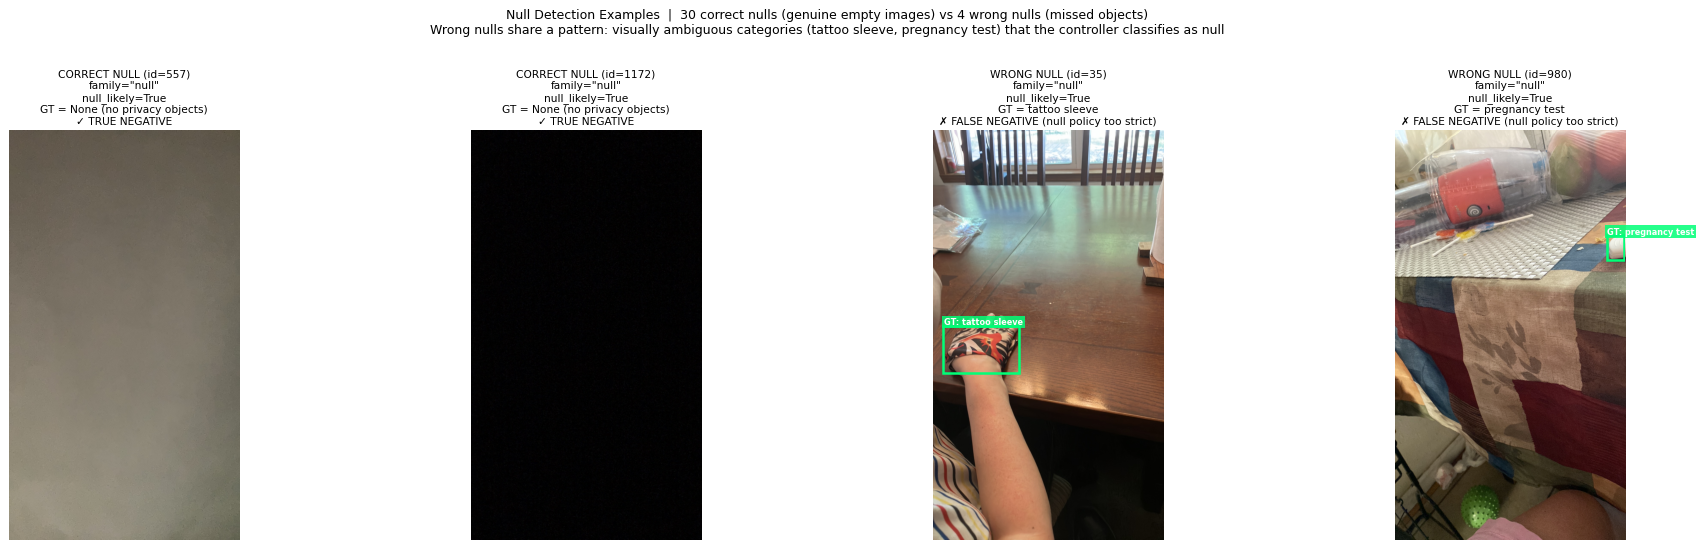

In [120]:
# Example 4: Correct Null Detection vs Wrong Null
# Side-by-side: what a 'correct null' looks like vs a 'wrong null' (tattoo sleeve)

fig, axes = plt.subplots(1, 4, figsize=(22, 6), dpi=90)

# Left: correct null id=557
iid_null = 557
r_null = exp1[iid_null]
img_null = load_img(iid_null)
draw_pipeline_panels(axes[0], img_null, [],
    title=f'CORRECT NULL (id={iid_null})\nfamily="{r_null["semantic_family"]}"\nnull_likely={r_null["null_likely"]}\nGT = None (no privacy objects)\n✓ TRUE NEGATIVE')

iid_null2 = 1172
r_null2 = exp1[iid_null2]
img_null2 = load_img(iid_null2)
draw_pipeline_panels(axes[1], img_null2, [],
    title=f'CORRECT NULL (id={iid_null2})\nfamily="{r_null2["semantic_family"]}"\nnull_likely={r_null2["null_likely"]}\nGT = None (no privacy objects)\n✓ TRUE NEGATIVE')

# Right: wrong null id=35 (tattoo sleeve) and id=23
iid_wn = 35
r_wn = exp1[iid_wn]
img_wn = load_img(iid_wn)
gt_wn = [(xywh_to_xyxy(ann['bbox']), f'GT: {cat_names[ann["category_id"]]}', '#00FF77')
         for ann in gt_by_img[iid_wn]]
draw_pipeline_panels(axes[2], img_wn, gt_wn,
    title=f'WRONG NULL (id={iid_wn})\nfamily="{r_wn["semantic_family"]}"\nnull_likely={r_wn["null_likely"]}\nGT = tattoo sleeve\n✗ FALSE NEGATIVE (null policy too strict)')

iid_wn2 = 980
r_wn2 = exp1[iid_wn2]
img_wn2 = load_img(iid_wn2)
gt_wn2 = [(xywh_to_xyxy(ann['bbox']), f'GT: {cat_names[ann["category_id"]]}', '#00FF77')
          for ann in gt_by_img[iid_wn2]]
draw_pipeline_panels(axes[3], img_wn2, gt_wn2,
    title=f'WRONG NULL (id={iid_wn2})\nfamily="{r_wn2["semantic_family"]}"\nnull_likely={r_wn2["null_likely"]}\nGT = pregnancy test\n✗ FALSE NEGATIVE (null policy too strict)')

fig.suptitle(
    'Null Detection Examples  |  30 correct nulls (genuine empty images) vs 4 wrong nulls (missed objects)\n'
    'Wrong nulls share a pattern: visually ambiguous categories (tattoo sleeve, pregnancy test) that the controller classifies as null',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()
